# How much should you trust a cross-modal prediction?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/experimental/prediction_uncertainty.ipynb)

> **Experimental.** `cross_modal_predict` returns one number per cell and feature. This notebook
> attaches uncertainty to those numbers and then checks, on held-out data, whether the uncertainty
> means anything.

Using RNA predicted from ATAC on 10x Multiome PBMCs:

1. **Posterior sampling.** Draw latent samples from each cell's ATAC posterior and decode them; the
   spread of the decoded values is the model's uncertainty about that cell's latent position.
2. **Does uncertainty track error?** Per cell and per gene, on held-out cells.
3. **Calibrated intervals.** Posterior spread ignores measurement noise, so raw intervals are too
   narrow. Split-conformal calibration on validation cells rescales them to a target coverage, which is
   then checked on test cells.
4. **Selective prediction.** If you keep only the most confident cells, how much better are the
   predictions (a risk–coverage curve)?
5. **An unseen cell type.** One cell type is removed from training entirely. Do its cells get higher
   uncertainty, and do the intervals still cover? Posterior spread is compared with a simple
   alternative novelty score, the distance to the nearest training cells in the latent space, and every
   score is also tested against the unseen type's closest relatives, not only against all other cells.
6. **Robustness.** The whole analysis is repeated with other held-out cell types.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.2" "pandas==2.2.3"

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
from IPython.display import display
from scipy.stats import norm, spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

import univi
import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import decode_from_latent, encode_adata
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)
dense = lambda x: x.toarray() if sp.issparse(x) else np.asarray(x)
print(f"UniVI {univi.__version__} on {device}")

UniVI 1.2.1 on cuda


C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101
N_SAMPLES = 30            # posterior samples per cell
COVERAGE = 0.90           # target coverage of the calibrated intervals
HELD_OUT_TYPE = None      # cell type removed from training; None picks one automatically (printed)
N_NEIGHBOR_TYPES = 2      # seen cell types closest to the unseen one, for the matched novelty test
EXTRA_HOLDOUTS = 2        # additional held-out cell types for the robustness check (0 to skip)

## 1. Data, with one cell type held out

All cells of `HELD_OUT_TYPE` are removed before splitting, so neither the preprocessing nor the model
sees them. By default the notebook picks the cell type whose size is the median among types with at
least 50 cells, which avoids both the dominant populations and tiny ones.

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
types = rna.obs["cell_type"].astype(str)
counts = types.value_counts()
if HELD_OUT_TYPE is None:
    eligible = counts[counts >= 50].sort_values()
    HELD_OUT_TYPE = eligible.index[len(eligible) // 2]
print(f"held-out cell type: {HELD_OUT_TYPE!r} ({counts[HELD_OUT_TYPE]} cells)")



def prepare(held_out):
    """Split without the held-out type, fit transforms on training cells only, and transform every split.

    train 70% / val 10% (early stopping) / cal 10% (conformal calibration) / test 10%.
    """
    seen = np.flatnonzero(types != held_out)
    split = split_by_label(types.iloc[seen], train_fraction=0.7, val_fraction=0.1, seed=0)
    rest = split["test"]
    halves = split_by_label(types.iloc[seen[rest]], train_fraction=0.5, val_fraction=0.0, seed=1)
    idx = {"train": seen[split["train"]], "val": seen[split["val"]],
           "cal": seen[rest[halves["train"]]], "test": seen[rest[halves["test"]]]}
    idx["unseen"] = np.flatnonzero(types == held_out)
    rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[idx["train"]])
    atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[idx["train"]])
    parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in idx.items()}
    return idx, parts


idx, parts = prepare(HELD_OUT_TYPE)
print({k: len(v) for k, v in idx.items()})

held-out cell type: 'Intermediate B' (300 cells)
{'train': 6523, 'val': 926, 'cal': 935, 'test': 947, 'unseen': 300}


Conformal calibration needs cells that played **no** part in fitting the model. Validation cells do play a
part: early stopping picks the checkpoint that fits them best, so they look slightly better than truly new
cells. A separate calibration split (`cal`, 10%) is therefore kept apart from the validation cells (10%)
that early stopping uses.

In [5]:
def train(parts):
    set_seed(0)
    cfg = UniVIConfig(
        latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
        kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
        modalities=[ModalityConfig("rna", parts["train"]["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
                    ModalityConfig("atac", parts["train"]["atac"].n_vars, [128, 64], [64, 128])])
    model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
    trainer = UniVITrainer(model, make_loader(parts["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
                           make_loader(parts["val"], batch_size=1024),
                           TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4,
                                          device=device, early_stopping=True, patience=50, best_epoch_warmup=110,
                                          log_every=50))
    trainer.fit()
    print("best epoch:", trainer.best_epoch)
    return model


model = train(parts)

[2026-09-23 12:35:33,396] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 12:35:33,397] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-23 12:35:33,397] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 12:35:33,398] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 12:35:33,398] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 12:35:33,399] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 12:35:33,399] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 12:35:33,400] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-23 12:35:33,400] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 12:35:33,400] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 12:35:33,401] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 12:35:33,401] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 12:35:33,402] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 12:35:33,402] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-23 12:35:34,520] [Uni

best epoch: 118


## 2. Posterior samples of predicted RNA

`encode_adata(..., latent="modality_sample", random_state=s)` draws one sample from each cell's ATAC
posterior; decoding the samples with `decode_from_latent` gives `N_SAMPLES` predicted RNA profiles per
cell. Their mean is (up to sampling) the usual prediction; their standard deviation is the posterior
uncertainty.

In [6]:
def predict_with_samples(model, adata_atac):
    draws = np.stack([decode_from_latent(model, encode_adata(model, adata_atac, modality="atac", device=device,
                                                             latent="modality_sample", random_state=s),
                                         device=device)["rna"]
                      for s in range(N_SAMPLES)])
    return draws.mean(0), draws.std(0, ddof=1)


pred = {k: predict_with_samples(model, parts[k]["atac"]) for k in ("cal", "test", "unseen")}
obs = {k: dense(parts[k]["rna"].X) for k in pred}
print({k: v[0].shape for k, v in pred.items()})

{'cal': (935, 2000), 'test': (947, 2000), 'unseen': (300, 2000)}


## 3. Does the spread track the error?

Two checks on held-out test cells of seen types:

- **per cell**: Spearman correlation between a cell's mean predictive s.d. and its mean squared error;
- **per gene**: across cells, Spearman correlation between s.d. and absolute error, for every gene.

per-cell Spearman(s.d., error): 0.234
per-gene Spearman(s.d., |error|): median 0.587; 97.5% of genes positive


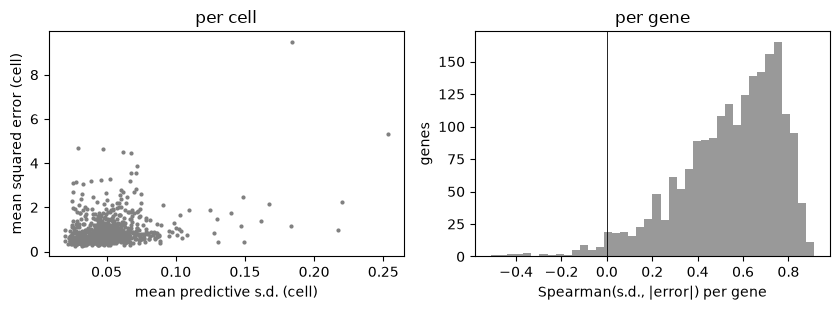

In [7]:
mean_t, sd_t = pred["test"]
err_t = (obs["test"] - mean_t) ** 2
cell_rho = spearmanr(sd_t.mean(1), err_t.mean(1)).statistic
gene_rho = pd.Series([spearmanr(sd_t[:, j], np.sqrt(err_t[:, j])).statistic for j in range(sd_t.shape[1])],
                     index=parts["test"]["rna"].var_names)
print(f"per-cell Spearman(s.d., error): {cell_rho:.3f}")
print(f"per-gene Spearman(s.d., |error|): median {gene_rho.median():.3f}; "
      f"{(gene_rho > 0).mean():.1%} of genes positive")

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
axes[0].scatter(sd_t.mean(1), err_t.mean(1), s=4, c="0.5")
axes[0].set(xlabel="mean predictive s.d. (cell)", ylabel="mean squared error (cell)", title="per cell")
axes[1].hist(gene_rho.dropna(), bins=40, color="0.6")
axes[1].axvline(0, c="k", lw=0.6)
axes[1].set(xlabel="Spearman(s.d., |error|) per gene", ylabel="genes", title="per gene")
plt.tight_layout()
plt.show()

## 4. Calibrated prediction intervals

The decoded samples describe uncertainty about the latent position, not measurement noise, so an
interval built directly from them (mean ± 1.645 s.d. for 90%) covers far fewer than 90% of observed
values. **Split-conformal prediction** fixes this with no distributional assumption: on calibration
cells, compute the normalized residual `|observed − mean| / s.d.` and take, per gene, its quantile at
the target coverage (with the standard finite-sample correction). The interval `mean ± q × s.d.` then
covers at least the target fraction of values of a new cell, **provided** the new cell is exchangeable
with the calibration cells (drawn from the same population). The unseen cell type breaks that
assumption, which Section 6 measures.

In [8]:
def conformal_quantiles(pred_val, obs_val):
    """Per-gene split-conformal quantile of |observed - mean| / s.d. on calibration cells."""
    eps = 1e-3 * np.median(pred_val[1])
    score = np.abs(obs_val - pred_val[0]) / (pred_val[1] + eps)
    n = score.shape[0]
    level = min(1.0, np.ceil((n + 1) * COVERAGE) / n)
    return np.quantile(score, level, axis=0, method="higher"), eps


def coverage(pred_split, obs_split, q, eps):
    m, s = pred_split
    inside = np.abs(obs_split - m) <= q * (s + eps)
    return inside.mean(), np.median(2 * q * (s + eps))


q_gene, eps = conformal_quantiles(pred["cal"], obs["cal"])
n_val = obs["cal"].shape[0]


z_naive = norm.ppf(0.5 + COVERAGE / 2)   # Gaussian quantile for a naive interval (1.645 for 90%)
rows = {}
for name in ("test", "unseen"):
    raw_cov, raw_width = coverage(pred[name], obs[name], np.full_like(q_gene, z_naive), eps)
    cal_cov, cal_width = coverage(pred[name], obs[name], q_gene, eps)
    rows[name] = {f"naive ±{z_naive:.3f} s.d. coverage": raw_cov, "conformal coverage": cal_cov,
                  "conformal median width": cal_width}
print(f"target coverage {COVERAGE:.0%}; per-gene conformal quantiles fit on {n_val} calibration cells")
pd.DataFrame(rows).T.rename(index={"test": "held-out cells, seen types",
                                   "unseen": f"unseen type: {HELD_OUT_TYPE}"}).round(3)

target coverage 90%; per-gene conformal quantiles fit on 935 calibration cells


,naive ±1.645 s.d. coverage,conformal coverage,conformal median width
"held-out cells, seen types",0.441,0.901,0.363
unseen type: Intermediate B,0.508,0.873,0.593


Coverage near the target on held-out cells of seen types is what the conformal guarantee predicts (it
holds on average over genes and cells, not for every gene). A clear shortfall on the unseen type means
the intervals should not be trusted for populations absent from the reference.

## 5. Selective prediction: keep the confident cells

Rank held-out cells by their mean predictive s.d. and compute prediction quality (per-cell Pearson
correlation between predicted and observed profiles) for the most confident fraction. A curve that
rises as coverage shrinks means uncertainty can be used to filter predictions.

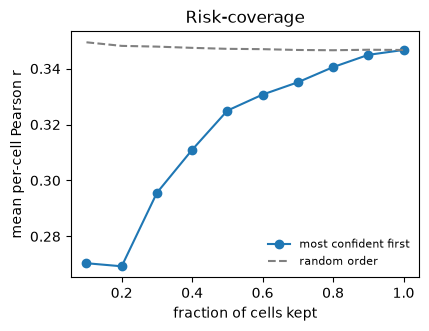

In [9]:
def per_cell_r(o, m):
    o = o - o.mean(1, keepdims=True)
    m = m - m.mean(1, keepdims=True)
    return (o * m).sum(1) / (np.linalg.norm(o, axis=1) * np.linalg.norm(m, axis=1) + 1e-12)


r_cell = per_cell_r(obs["test"], mean_t)
order = np.argsort(sd_t.mean(1))
fractions = np.linspace(0.1, 1.0, 10)
curve = [r_cell[order[: max(1, int(f * len(order)))]].mean() for f in fractions]
rand = [np.mean([r_cell[np.random.default_rng(b).permutation(len(order))[: max(1, int(f * len(order)))]].mean()
                 for b in range(50)]) for f in fractions]
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.plot(fractions, curve, marker="o", label="most confident first")
ax.plot(fractions, rand, ls="--", c="0.5", label="random order")
ax.set(xlabel="fraction of cells kept", ylabel="mean per-cell Pearson r", title="Risk-coverage")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 6. Does uncertainty flag a cell type the model never saw?

Three candidate novelty scores for each cell, compared by how well they separate unseen-type cells from
held-out cells of seen types (AUROC):

- **predictive s.d.**: mean s.d. of the decoded samples;
- **posterior variance**: the ATAC encoder's own variance, summed over latent dimensions;
- **latent kNN distance**: mean distance to the 15 nearest training cells in the ATAC latent space.

An AUROC of 0.5 means no separation, and an AUROC **below** 0.5 is also separation, in the other
direction (the unseen cells score *lower*); the table reports the direction and `separation =
max(AUROC, 1 - AUROC)`. Variational autoencoders are not guaranteed to be more uncertain on new
inputs, and encoders are often *more* confident on them.

A score can also separate an unseen type from "all other cells" simply because it differs between
lineages: if B cells always get a high predictive s.d., an unseen B-cell subtype will too, without
anything being detected as new. The **matched** test therefore compares the unseen type only with the
`N_NEIGHBOR_TYPES` seen types whose training cells lie closest to it in the RNA latent space.

In [10]:
def posterior_variance(model, adata):
    x = torch.as_tensor(dense(adata.X), dtype=torch.float32, device=device)
    model.eval()
    with torch.no_grad():
        _, logvar = model.encode_modalities({"atac": x})
    return logvar["atac"].exp().sum(1).cpu().numpy()


def novelty_scores(model, parts, pred):
    z_train = encode_adata(model, parts["train"]["atac"], modality="atac", device=device, latent="modality_mean")
    nn = NearestNeighbors(n_neighbors=15).fit(z_train)
    knn = {k: nn.kneighbors(encode_adata(model, parts[k]["atac"], modality="atac", device=device,
                                         latent="modality_mean"))[0].mean(1) for k in ("test", "unseen")}
    return {"predictive s.d.": {k: pred[k][1].mean(1) for k in ("test", "unseen")},
            "posterior variance": {k: posterior_variance(model, parts[k]["atac"]) for k in ("test", "unseen")},
            "latent kNN distance": knn}


def nearest_seen_types(model, parts, idx, n):
    """Seen cell types whose training-cell centroid (RNA latent) is closest to the unseen type's centroid."""
    z_tr = encode_adata(model, parts["train"]["rna"], modality="rna", device=device, latent="modality_mean")
    z_un = encode_adata(model, parts["unseen"]["rna"], modality="rna", device=device, latent="modality_mean")
    cent = pd.DataFrame(z_tr).groupby(types.iloc[idx["train"]].to_numpy()).mean()
    dist = np.linalg.norm(cent.to_numpy() - z_un.mean(0), axis=1)
    return list(cent.index[np.argsort(dist)[:n]])


def auroc_table(scores, idx, neighbors):
    test_types = types.iloc[idx["test"]].to_numpy()
    near = np.isin(test_types, neighbors)
    rows = {}
    for name, sc_ in scores.items():
        for label, mask in [("all seen types", np.ones_like(near)), ("nearest seen types", near)]:
            yy = np.r_[np.zeros(mask.sum()), np.ones(len(sc_["unseen"]))]
            a = roc_auc_score(yy, np.r_[sc_["test"][mask], sc_["unseen"]])
            rows[(name, label)] = {"AUROC": a, "separation": max(a, 1 - a),
                                   "unseen type scores": "higher" if a >= 0.5 else "lower"}
    return pd.DataFrame(rows).T.astype({"AUROC": float, "separation": float})


scores = novelty_scores(model, parts, pred)
neighbors = nearest_seen_types(model, parts, idx, N_NEIGHBOR_TYPES)
print(f"unseen type {HELD_OUT_TYPE!r}; nearest seen types: {neighbors}")
novelty = auroc_table(scores, idx, neighbors)
display(novelty.round(3))

unseen type 'Intermediate B'; nearest seen types: ['Naive B', 'Memory B']


AUROC  separation unseen type scores
predictive s.d.     all seen types      0.908       0.908             higher
                    nearest seen types  0.826       0.826             higher
posterior variance  all seen types      0.036       0.964              lower
                    nearest seen types  0.202       0.798              lower
latent kNN distance all seen types      0.721       0.721             higher
                    nearest seen types  0.906       0.906             higher

Scores by cell type show whether a score tracks novelty or lineage: a score that is high for the unseen
type *and* for its seen relatives is describing the lineage.

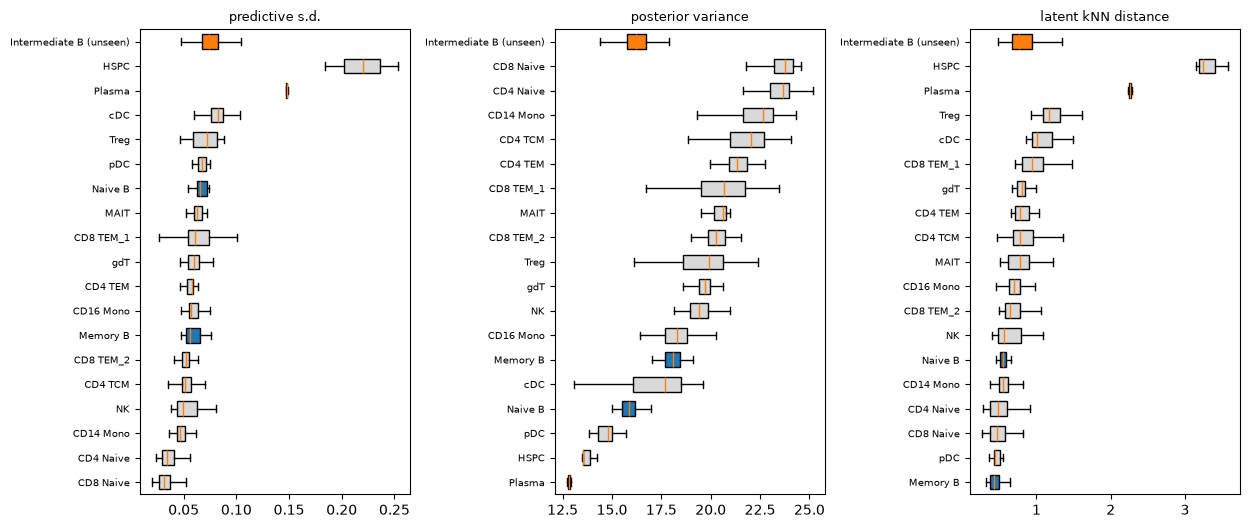

In [11]:
test_types = types.iloc[idx["test"]].to_numpy()
fig, axes = plt.subplots(1, len(scores), figsize=(4.2 * len(scores), 0.22 * (len(set(test_types)) + 1) + 1.2))
for ax, (name, sc_) in zip(np.atleast_1d(axes), scores.items()):
    per_type = pd.Series(sc_["test"], index=test_types)
    order = list(per_type.groupby(level=0).median().sort_values().index)
    data_ = [per_type.loc[t].to_numpy() for t in order] + [sc_["unseen"]]
    labels_ = order + [f"{HELD_OUT_TYPE} (unseen)"]
    mpl_version = tuple(int(v) for v in matplotlib.__version__.split(".")[:2])
    horizontal = {"orientation": "horizontal"} if mpl_version >= (3, 10) else {"vert": False}
    bp = ax.boxplot(data_, showfliers=False, patch_artist=True, widths=0.6, **horizontal)
    for patch, lab in zip(bp["boxes"], labels_):
        patch.set_facecolor("C1" if "(unseen)" in lab else ("C0" if lab in neighbors else "0.85"))
    ax.set_yticks(range(1, len(labels_) + 1), labels_, fontsize=7)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

Orange is the unseen type and blue its nearest seen types. If the matched AUROC is much closer to 0.5
than the AUROC against all seen types, most of the apparent novelty signal is lineage.

## 7. Does it hold for other held-out cell types?

One held-out cell type is one example. Here the whole pipeline (split, transforms, training, sampling,
conformal calibration, novelty scores) is re-run with `EXTRA_HOLDOUTS` other cell types, chosen
automatically among types with at least 50 cells at different sizes. Each run trains a new model.

In [12]:
def evaluate_holdout(held_out):
    idx_h, parts_h = prepare(held_out)
    model_h = train(parts_h)
    pred_h = {k: predict_with_samples(model_h, parts_h[k]["atac"]) for k in ("cal", "test", "unseen")}
    obs_h = {k: dense(parts_h[k]["rna"].X) for k in pred_h}
    q_h, eps_h = conformal_quantiles(pred_h["cal"], obs_h["cal"])
    row = {"cells": len(idx_h["unseen"]),
           "coverage, seen": coverage(pred_h["test"], obs_h["test"], q_h, eps_h)[0],
           "coverage, unseen": coverage(pred_h["unseen"], obs_h["unseen"], q_h, eps_h)[0]}
    tab = auroc_table(novelty_scores(model_h, parts_h, pred_h), idx_h,
                      nearest_seen_types(model_h, parts_h, idx_h, N_NEIGHBOR_TYPES))
    for (name, label), r in tab.iterrows():
        row[f"{name} | {'all' if label.startswith('all') else 'nearest'}"] = r["AUROC"]
    return row


robust = {HELD_OUT_TYPE: {"cells": len(idx["unseen"]),
                          "coverage, seen": rows["test"]["conformal coverage"],
                          "coverage, unseen": rows["unseen"]["conformal coverage"],
                          **{f"{n} | {'all' if l.startswith('all') else 'nearest'}": r["AUROC"]
                             for (n, l), r in novelty.iterrows()}}}
if EXTRA_HOLDOUTS > 0:
    eligible = counts[(counts >= 50) & (counts.index != HELD_OUT_TYPE)].sort_values()
    picks = [eligible.index[int(q * (len(eligible) - 1))] for q in np.linspace(0.2, 0.8, EXTRA_HOLDOUTS)]
    for t in dict.fromkeys(picks):
        print(f"--- holding out {t!r}")
        robust[t] = evaluate_holdout(t)
robust = pd.DataFrame(robust).T
robust.round(3)

--- holding out 'gdT'


[2026-09-23 12:39:31,429] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 12:39:31,430] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-23 12:39:31,431] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 12:39:31,432] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 12:39:31,433] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 12:39:31,433] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 12:39:31,434] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 12:39:31,434] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-23 12:39:31,434] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 12:39:31,435] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 12:39:31,435] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 12:39:31,436] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 12:39:31,436] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 12:39:31,437] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-23 12:39:32,138] [Uni

best epoch: 111
--- holding out 'CD4 TCM'


[2026-09-23 12:42:51,163] [UniVITrainer] [INFO] TrainingConfig:
[2026-09-23 12:42:51,164] [UniVITrainer] [INFO]   n_epochs: 400
[2026-09-23 12:42:51,164] [UniVITrainer] [INFO]   batch_size: 256
[2026-09-23 12:42:51,165] [UniVITrainer] [INFO]   lr: 0.001
[2026-09-23 12:42:51,166] [UniVITrainer] [INFO]   weight_decay: 0.0001
[2026-09-23 12:42:51,166] [UniVITrainer] [INFO]   device: 'cuda'
[2026-09-23 12:42:51,167] [UniVITrainer] [INFO]   log_every: 50
[2026-09-23 12:42:51,167] [UniVITrainer] [INFO]   grad_clip: None
[2026-09-23 12:42:51,168] [UniVITrainer] [INFO]   num_workers: 0
[2026-09-23 12:42:51,168] [UniVITrainer] [INFO]   seed: 0
[2026-09-23 12:42:51,168] [UniVITrainer] [INFO]   early_stopping: True
[2026-09-23 12:42:51,169] [UniVITrainer] [INFO]   patience: 50
[2026-09-23 12:42:51,169] [UniVITrainer] [INFO]   min_delta: 0.0
[2026-09-23 12:42:51,169] [UniVITrainer] [INFO]   best_epoch_warmup: 110
Training UniVI:   0%|          | 0/400 [00:00<?, ?it/s][2026-09-23 12:42:51,727] [Uni

best epoch: 131


,cells,"coverage, seen","coverage, unseen",predictive s.d. | all,predictive s.d. | nearest,posterior variance | all,posterior variance | nearest,latent kNN distance | all,latent kNN distance | nearest
Intermediate B,300.0,0.901,0.873,0.908,0.826,0.036,0.202,0.721,0.906
gdT,143.0,0.902,0.927,0.779,0.639,0.248,0.370,0.872,0.799
CD4 TCM,1113.0,0.900,0.955,0.697,0.879,0.401,0.114,0.808,0.916


Read the AUROC columns as separation in either direction (values near 0 are as informative as values
near 1). A score is a useful novelty detector here only if it separates the unseen type from its
nearest relatives consistently, in the same direction, across held-out types. (In our real-data run,
predictive s.d. did, while the direction of posterior variance changed from one held-out type to another.)


## Using this in practice

- Report predicted features **with** their conformal intervals, and state the calibration population.
  The coverage guarantee holds for new cells drawn from the same population as the calibration cells.
- Use a novelty score (whichever separated best in Section 6) to flag query cells that look unlike the
  reference, and treat their predictions as unreliable regardless of interval width.
- Everything here works for any source and target modality: replace `"atac"` and `"rna"` in
  `predict_with_samples`, for example to put intervals on protein predicted from RNA in CITE-seq.